# Check the outputs from the scANVI predictions and the majority voting done on the scANVI predictions

In [1]:
# SET UP DEPENDENCIES

import sys
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpascvi

# version control
print("\nPackage versions:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)

mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.rcParams['axes.facecolor'] = 'white'
sc.settings.n_jobs = -1  # Use all available cores

/home/jpagolia/miniforge3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Package versions:
pandas: 2.3.1
numpy: 2.2.6
scanpy: 1.11.4


In [2]:
# SET UP DIRECTORIES

CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
print(PARENT_DIR)

G4X_DIR = PARENT_DIR.parent / 'G4X'
print(G4X_DIR)

SCANVI_DIR = PARENT_DIR.parent / 'multimodal/scANVI_tumor_allgenes'

SCANVI_FULL_DIR = jpascvi.create_output_dir(SCANVI_DIR, 'scanvi_full') # where scANVI full adata with predictions is saved
OUTPUT_MASTER_DIR = jpascvi.create_output_dir(SCANVI_DIR, 'scanvi_tumor_corr', change_figdir=True) # new subdirectory for outputs

/oak/stanford/groups/longaker/ULMS/revision/multimodal
/oak/stanford/groups/longaker/ULMS/revision/G4X
Created output directory /oak/stanford/groups/longaker/ULMS/revision/multimodal/scANVI_tumor_allgenes/scanvi_full
Created output directory /oak/stanford/groups/longaker/ULMS/revision/multimodal/scANVI_tumor_allgenes/scanvi_tumor_corr
Default scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/multimodal/scANVI_tumor_allgenes/scanvi_tumor_corr


In [3]:
# USER PARAMETERS
cell_type_key = 'tumor_subtype' # key in the G4X anndata obs where the tumor subtype annotations will be stored
leiden_key = 'leiden1_5' # leiden clustering key in the G4X data to use for majority voting
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTIONS_KEY = "scanvi_pred"

In [4]:
adata = sc.read_h5ad(OUTPUT_MASTER_DIR / 'scviva_tumor_scanvi_pred.h5ad')
adata

AnnData object with n_obs × n_vars = 1597386 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0', 'tumor_subtype', 'scanvi_pred', 'cell_type_majority', 'majority_confidence'
    var: 'mean', 'std'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'cell_type_majority_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1

In [5]:
adata.obs.columns

Index(['cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z',
       'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'n_counts', 'n_genes', 'Patient',
       'true_proportion', 'diffusion_proportion', 'background_proportion',
       'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct',
       'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3',
       'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8',
       'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3',
       'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8',
       'leiden1_9', 'leiden2_0', 'tumor_subtype', 'scanvi_pred',
       'cell_type_majority', 'majority_confidence'],
      dtype='object')

In [6]:
np.unique(adata.obs['scanvi_pred'])

array(['AR+/PGR+ cells', 'ATRX+/DAXX- cells', 'Cycling cells',
       'ESR1+ cells', 'IFN signaling cells', 'Ischemic cells',
       'Mesenchyme-like cells', 'Neuron-like cells', 'SMC-like cells'],
      dtype=object)

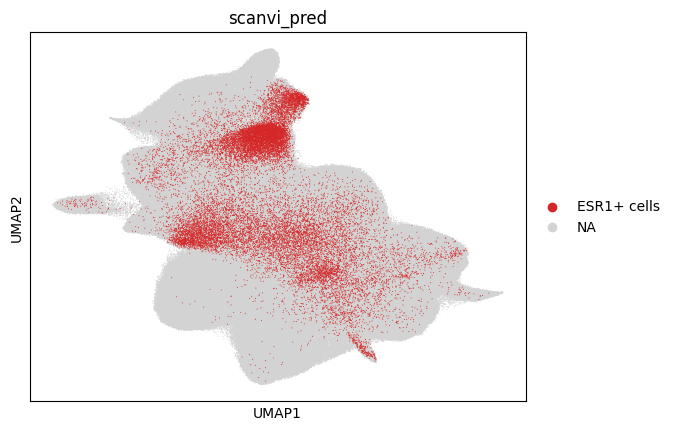

In [7]:
sc.pl.umap(adata, color='scanvi_pred', groups='ESR1+ cells', size=2)

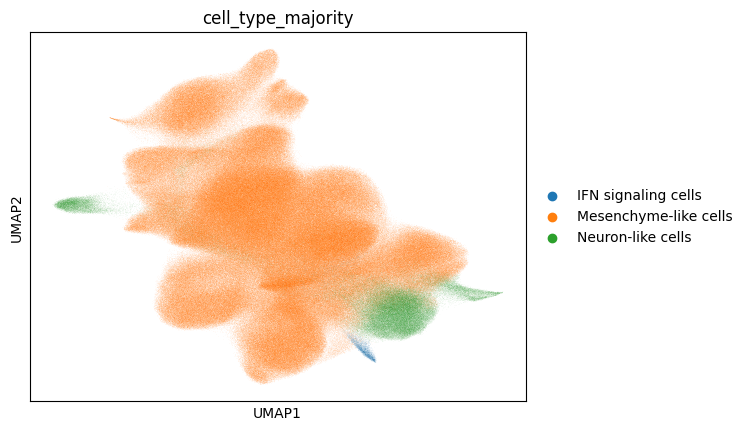

In [8]:
sc.pl.umap(adata, color='cell_type_majority')

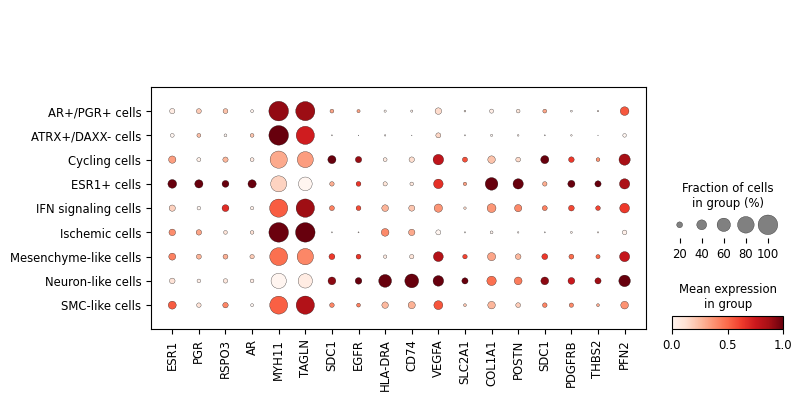

In [9]:
markers = [
    'ESR1', 'PGR', 'RSPO3', 'AR',
    'MYH11', 'TAGLN',
    'SDC1', 'EGFR',
    'HLA-DRA', 'CD74',
    'VEGFA', 'SLC2A1',
    'COL1A1', 'POSTN',
    'SDC1', 'PDGFRB',
    'THBS2', 'PFN2',
]
sc.pl.dotplot(adata, var_names=markers, groupby='scanvi_pred', dendrogram=False, standard_scale='var')

In [10]:
# if dendrogram has not already been computed, compute the dendrogram for each cluster
sc.tl.dendrogram(adata, groupby='scanvi_pred', use_rep='X_scVIVA')

In [11]:
# Calculate differentially expressed genes per cluster compared to all other clusters using scanpy method (one vs all)
sc.tl.rank_genes_groups(adata, groupby='scanvi_pred', method="wilcoxon") # using lognorm data in adata.raw is the default

In [12]:
# saving the dataframe with all the degs
de_df = sc.get.rank_genes_groups_df(adata, group=None)
csv_path = OUTPUT_MASTER_DIR / 'scanvi_pred_all_degs.csv'
de_df.to_csv(csv_path, index=False)

# filter for top 100 degs for each cluster before saving the dataframe
cats = adata.obs['scanvi_pred'].cat.categories
top100 = pd.DataFrame()
for c in cats:
    de_filt = de_df[de_df['group'] == c]
    de_filt = de_filt[de_filt['logfoldchanges'] > 0]
    de_filt = de_filt[de_filt['pvals_adj'] < 0.05]
    de_filt = de_filt.sort_values('scores', kind='mergesort', ascending=False)
    de_filt = de_filt.head(n=100)
    top100 = pd.concat([top100, de_filt], axis=0)
# write degs df - the filtered one
csv_path = OUTPUT_MASTER_DIR / 'scanvi_pred_top100_degs.csv'
top100.to_csv(csv_path)

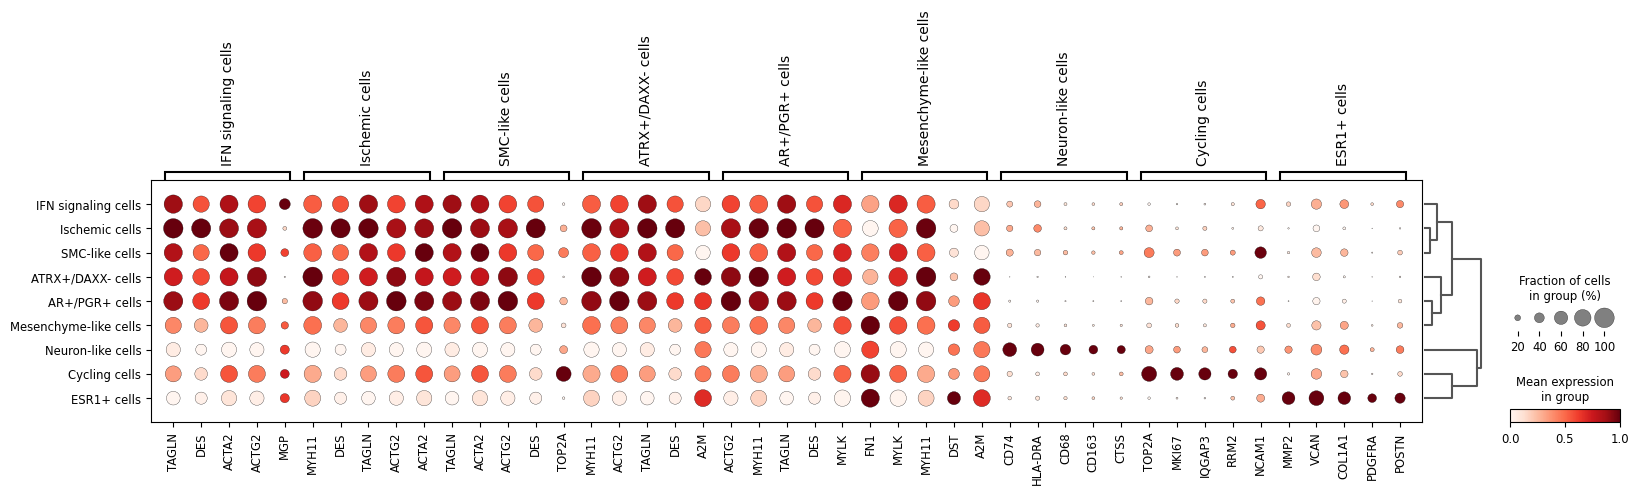

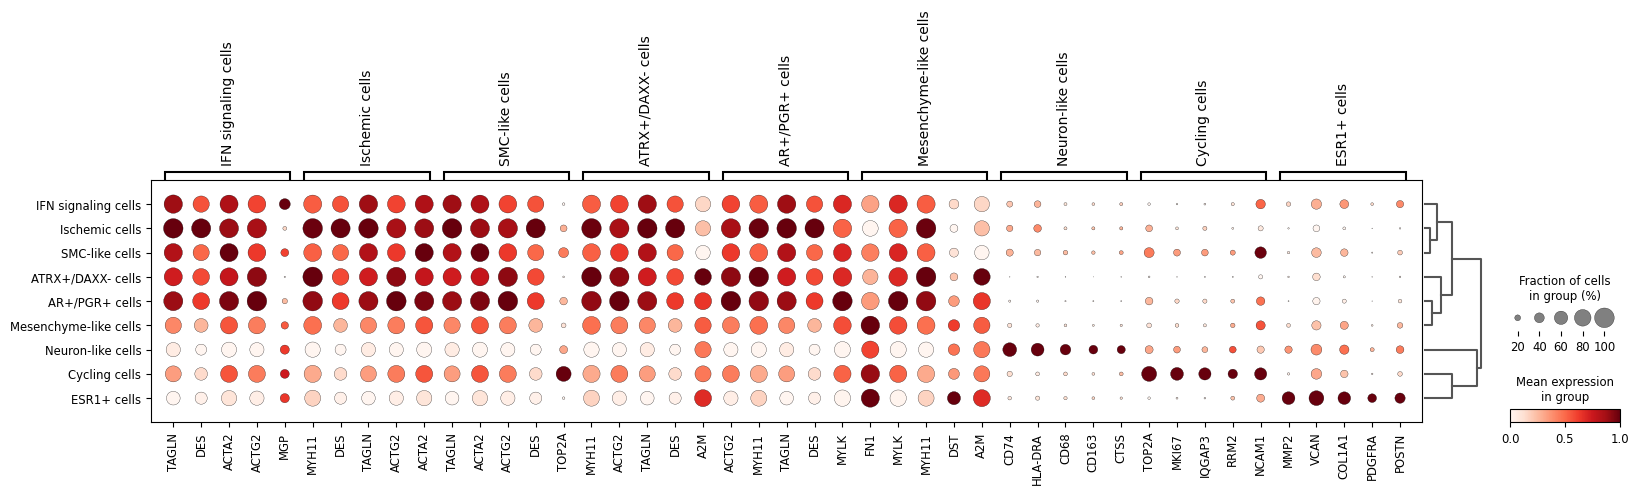

In [13]:
rank_genes_filename = 'scanvi_pred_top_genes.png'
sc.pl.rank_genes_groups_dotplot(adata, groupby='scanvi_pred', standard_scale="var", n_genes=5, save=rank_genes_filename)
rank_genes_filename = 'scanvi_pred_top_genes.pdf'
sc.pl.rank_genes_groups_dotplot(adata, groupby='scanvi_pred', standard_scale="var", n_genes=5, save=rank_genes_filename)

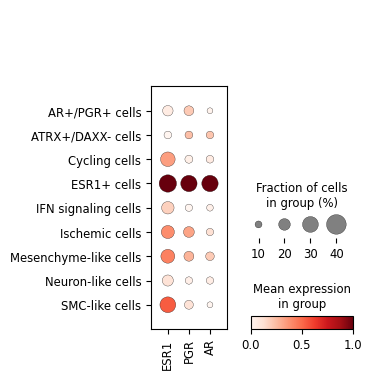

In [14]:
sc.pl.dotplot(adata, groupby='scanvi_pred', standard_scale="var", var_names=['ESR1', 'PGR', 'AR'], save='scanvi_pred_esr1_pgr_ar.png')

# Load scRNAseq tumor raw data and check

In [15]:
SCRNASEQ_DIR = PARENT_DIR.parent / 'scRNAseq'
data_dir = SCRNASEQ_DIR / 'objects'
adata_sc = sc.read_h5ad(data_dir / 'tumor_subset_raw.h5ad')
adata_sc

AnnData object with n_obs × n_vars = 93180 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', 'celltype', 'leiden0_2'

In [16]:
annotation_map = {
    "0" : "ESR1+ cells",
    "1" : "IFN signaling cells",
    "2" : "Mesenchyme-like cells",
    "3" : "Cycling cells",
    "4" : "AR+/PGR+ cells",
    "5" : "Ischemic cells",
    "6" : "SMC-like cells",
    "7" : "Neuron-like cells",
    "8" : "ATRX+/DAXX- cells"
}
adata_sc.obs['annotation'] = adata_sc.obs['leiden0_2'].map(annotation_map)
# Set the order of the categories
celltype_order = [
    "AR+/PGR+ cells",
    "ESR1+ cells",
    "SMC-like cells",
    "IFN signaling cells",
    "Cycling cells",
    "Ischemic cells",
    "Mesenchyme-like cells",
    "Neuron-like cells",
    "ATRX+/DAXX- cells"
]
# Make sure the color map is consistent
celltype_colors = {
    "AR+/PGR+ cells" : '#55a868',
    "ESR1+ cells" : '#4c72b0',
    "SMC-like cells" : '#da8bc3',
    "IFN signaling cells" : '#c44e52',
    "Cycling cells" : '#937860',
    "Ischemic cells" : '#8172b3',
    "Mesenchyme-like cells" : '#dd8452',
    "Neuron-like cells" : '#8c8c8c',
    "ATRX+/DAXX- cells" : '#ccb974',
}
adata_sc.obs["annotation"] = pd.Categorical(adata_sc.obs["annotation"], categories=celltype_order, ordered=True)
adata_sc.uns['annotation_colors'] = [celltype_colors[celltype] for celltype in celltype_order]

In [17]:
adata_sc.obs['annotation']

CCTGTTGGTTCGATTG-1_Batch01               ESR1+ cells
GAAACCTTCCTGGGTG-1_Batch01            AR+/PGR+ cells
CAGGCCAAGCCGCACT-1_Batch01            AR+/PGR+ cells
AGCTCAACACGTATAC-1_Batch01            AR+/PGR+ cells
TCATACTAGTCTGCGC-1_Batch01             Cycling cells
                                       ...          
GTTCTCAGTCCTTGTA-1_Sample23           Ischemic cells
GGACGGAGTCTGTACC-1_Sample23    Mesenchyme-like cells
AGCCCCTTCCTCGCTA-1_Sample23           Ischemic cells
CCCACTATCCCTGACC-1_Sample23           Ischemic cells
GCGGTATTCGGGCTCA-1_Sample23    Mesenchyme-like cells
Name: annotation, Length: 93180, dtype: category
Categories (9, object): ['AR+/PGR+ cells' < 'ESR1+ cells' < 'SMC-like cells' < 'IFN signaling cells' ... 'Ischemic cells' < 'Mesenchyme-like cells' < 'Neuron-like cells' < 'ATRX+/DAXX- cells']

In [18]:
adata_sc.layers['counts'] = adata_sc.X
sc.pp.normalize_total(adata_sc)
sc.pp.log1p(adata_sc)
adata_sc.layers['lognorm'] = adata_sc.X

g4x_genes = adata.var_names.to_list()
adata_sc = adata_sc[:, g4x_genes].copy()

adata_sc.raw = adata_sc
sc.pp.scale(adata_sc, max_value=10)

/home/jpagolia/miniforge3/envs/scvi-env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [19]:
# Calculate differentially expressed genes per cluster compared to all other clusters using scanpy method (one vs all)
sc.tl.rank_genes_groups(adata_sc, groupby='annotation', method="wilcoxon")

In [20]:
# saving the dataframe with all the degs
de_df = sc.get.rank_genes_groups_df(adata_sc, group=None)
csv_path = OUTPUT_MASTER_DIR / 'scrnaseq_tumor_subtype_all_degs.csv'
de_df.to_csv(csv_path, index=False)

# filter for top 100 degs for each cluster before saving the dataframe
cats = adata_sc.obs['annotation'].cat.categories
top100 = pd.DataFrame()
for c in cats:
    de_filt = de_df[de_df['group'] == c]
    de_filt = de_filt[de_filt['logfoldchanges'] > 0]
    de_filt = de_filt[de_filt['pvals_adj'] < 0.05]
    de_filt = de_filt.sort_values('scores', kind='mergesort', ascending=False)
    de_filt = de_filt.head(n=100)
    top100 = pd.concat([top100, de_filt], axis=0)
# write degs df - the filtered one
csv_path = OUTPUT_MASTER_DIR / 'scrnaseq_tumor_subtype_top100_degs.csv'
top100.to_csv(csv_path)

/home/jpagolia/miniforge3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 304 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


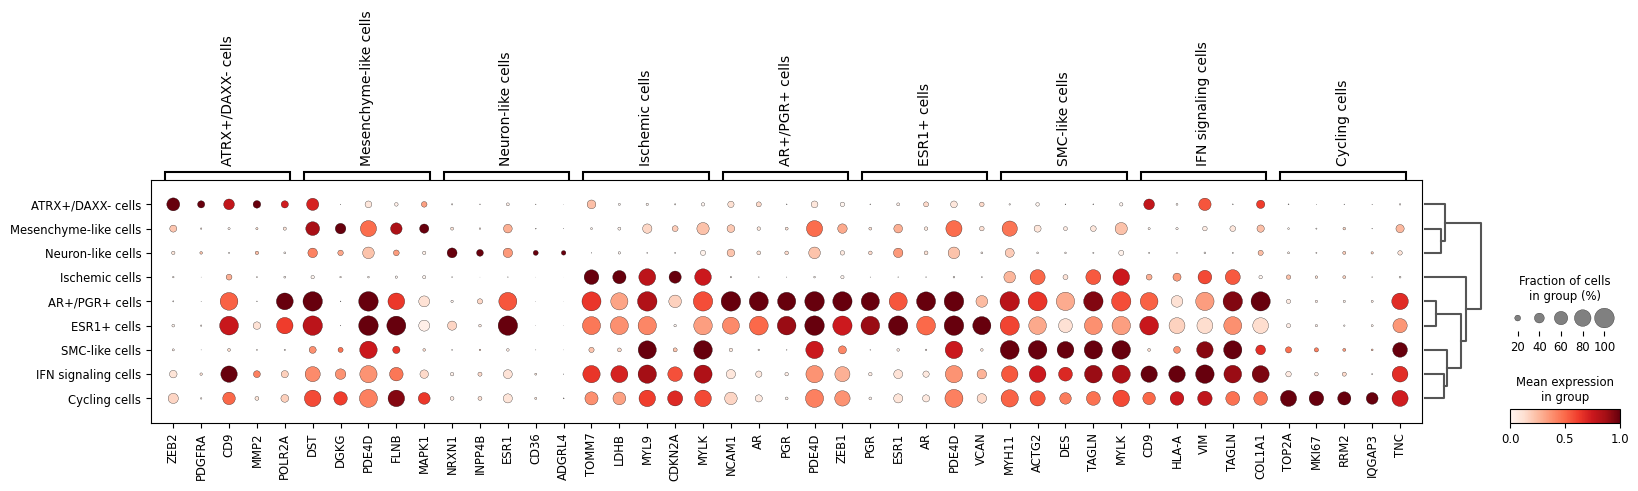

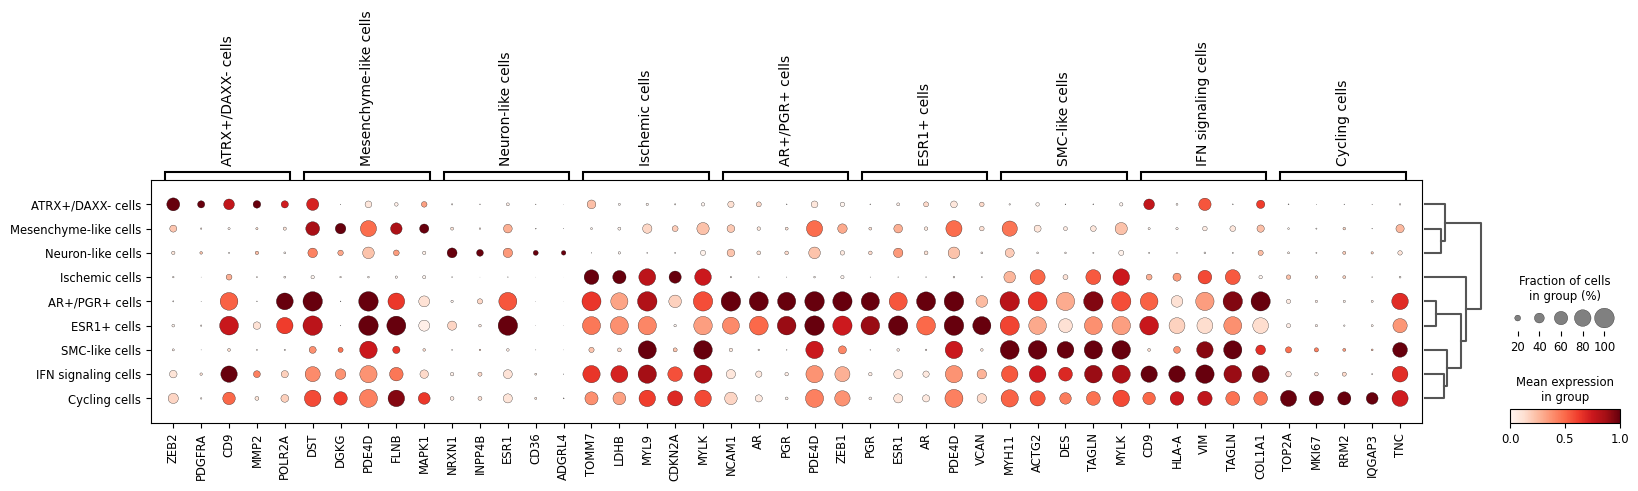

In [21]:
rank_genes_filename = 'scrnaseq_tumor_subtype_top_genes.png'
sc.pl.rank_genes_groups_dotplot(adata_sc, groupby='annotation', standard_scale="var", n_genes=5, save=rank_genes_filename)
rank_genes_filename = 'scrnaseq_tumor_subtype_top_genes.pdf'
sc.pl.rank_genes_groups_dotplot(adata_sc, groupby='annotation', standard_scale="var", n_genes=5, save=rank_genes_filename)